# IVF Pregnancy Prediction Pipeline

## 핵심 개선 사항

### 🔑 v7에서 놓친 핵심 변수 발굴 (데이터 분석 기반)
| 변수 | 단독 AUC | v9 처리 | v10 처리 |
|---|---|---|---|
| `배아 이식 경과일` | **0.676** | 단순 결측치 대치 | ordinal score + 핵심 파생변수 원천 |
| `나이보정 이식일` | **0.686** | 없음 | 신규 생성 |
| `이식일+배아수 combo` | **0.696** | 없음 | 신규 생성 |
| `BLASTOCYST 여부` | 0.621 | 없음 | 특정 시술 유형 파싱 |
| `procedure_dual(:패턴)` | - | 없음 | 반복실패 신호 |

### 📊 데이터 핵심 인사이트
- **배아 이식 경과일 5일** = 블라스토시스트 이식 → 성공률 40.4% (전체 25.8%)
- **배아 이식 경과일 결측** = DI(인공수정) 환자 → 성공률 12.9% → 결측 자체가 강한 신호
- **`특정 시술 유형`의 `:` 패턴** (예: IVF:IVF) = 반복 시술 실패 기록 → 성공률 1%
- **BLASTOCYST 포함 시술** → 성공률 36.1% vs 일반 25.7%

### ⚡ 모델 단순화 전략
- **단일 LightGBM** (CatBoost 제거 → 실행시간 절반 단축)
- Optuna 20 trials, 5-fold CV
- OOF: 3 seeds × 5-fold
- 예상 실행시간: **30~50분** (CPU 환경)

### ✅ Leakage 방지 확인
- 모든 통계값(median, mode)은 train에서만 계산 → test에 적용
- LabelEncoder는 train fit → test transform
- 고결측 플래그는 train 결측률 기준으로만 판단

## 설치

In [1]:
!pip install optuna lightgbm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 10.8 MB/s eta 0:00:00


## 라이브러리 임포트

In [2]:
import pandas as pd
import numpy as np
import time

import lightgbm as lgb

import optuna
from optuna.samplers import TPESampler

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

## 데이터 로드

In [3]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

TARGET = '임신 성공 여부'
ID_COL = 'ID'

print(f'Train: {train.shape}, Test: {test.shape}')
print(f'Target 분포:\n{train[TARGET].value_counts()}')
print(f'양성 비율: {train[TARGET].mean():.4f}')

Train: (256351, 69), Test: (90067, 68)
Target 분포:
임신 성공 여부
0    190123
1     66228
Name: count, dtype: int64
양성 비율: 0.2583


## 전처리 함수 정의

### 핵심 설계 원칙
- **Leakage-free**: 모든 통계는 train 기준 계산 후 test에 적용
- **바이오 도메인 이상치**: 임상 가이드라인 기반 상한값으로 NaN 처리
- **배아 이식 경과일**: v9 미활용 → v10 핵심 파생변수 원천으로 격상

### 바이오 도메인 이상치 기준
| 변수 | 상한 | 근거 |
|---|---|---|
| `총 생성 배아 수` | 40 | Humaidan et al. 2010 |
| `혼합된 난자 수` | 50 | Verberg et al. 2009 |
| `이식된 배아 수` | 5 | ESHRE/ASRM 가이드라인 |
| `총 시술 횟수` | 20 | Olivius et al. 2004 |
| `총 임신 횟수` | 10 | 논리적 제약 |
| `시술 당시 나이` | 18-50 | 임상 연령 범위 |

In [4]:
# ═══════════════════════════════════════════════════════
# 상수 정의
# ═══════════════════════════════════════════════════════
COUNT_COLS = [
    '총 시술 횟수', '클리닉 내 총 시술 횟수', 'IVF 시술 횟수', 'DI 시술 횟수',
    '총 임신 횟수', 'IVF 임신 횟수', 'DI 임신 횟수',
    '총 출산 횟수', 'IVF 출산 횟수', 'DI 출산 횟수'
]

AGE_MAP = {
    '만18-34세': 26, '만35-37세': 36, '만38-39세': 38.5,
    '만40-42세': 41, '만43-44세': 43.5, '만45-50세': 47, '알 수 없음': np.nan
}

BIO_BOUNDS = {
    '총 생성 배아 수':  (0, 40),
    '혼합된 난자 수':   (0, 50),
    '이식된 배아 수':   (0, 5),
    '총 시술 횟수':     (0, 20),
    '총 임신 횟수':     (0, 10),
    '시술 당시 나이':   (18, 50),
}

# ═══════════════════════════════════════════════════════
# Step 1. 기본 타입 변환
# ═══════════════════════════════════════════════════════
def convert_types(df):
    """문자열 → 수치 변환: 나이(ordinal→중앙값), 횟수('N회'→N)"""
    df = df.copy()

    # 나이: 구간 문자열 → 구간 중앙값
    if '시술 당시 나이' in df.columns:
        df['시술 당시 나이'] = df['시술 당시 나이'].map(AGE_MAP)

    # 횟수 컬럼: '3회' → 3.0, '6회 이상' → 6.0
    for col in COUNT_COLS:
        if col in df.columns:
            df[col] = df[col].astype(str).str.extract(r'(\d+)')[0].astype(float)

    return df

# ═══════════════════════════════════════════════════════
# Step 2. 바이오 도메인 이상치 → NaN
# ═══════════════════════════════════════════════════════
def apply_bio_bounds(df):
    """임상 가이드라인 벗어난 값 → NaN (IQR 클리핑 없음)"""
    df = df.copy()
    for col, (lo, hi) in BIO_BOUNDS.items():
        if col not in df.columns:
            continue
        s = pd.to_numeric(df[col], errors='coerce')
        if lo is not None: s = s.where(s >= lo, np.nan)
        if hi is not None: s = s.where(s <= hi, np.nan)
        df[col] = s

    # 논리적 제약: 임신 횟수 > 시술 횟수는 불가 → 캡핑
    if '총 임신 횟수' in df.columns and '총 시술 횟수' in df.columns:
        mask = df['총 임신 횟수'] > df['총 시술 횟수']
        df.loc[mask, '총 임신 횟수'] = df.loc[mask, '총 시술 횟수']

    return df

# ═══════════════════════════════════════════════════════
# Step 3. 결측치 대치 (Leakage-free)
# ═══════════════════════════════════════════════════════
def fit_imputer(train_df):
    """train에서 통계값 계산 (test에 그대로 적용)"""
    medians, modes = {}, {}
    num_cols = [c for c in train_df.select_dtypes(include=[np.number]).columns if c != TARGET]
    str_cols  = [c for c in train_df.columns if train_df[c].dtype == object]
    for col in num_cols:
        medians[col] = train_df[col].median()
    for col in str_cols:
        modes[col] = train_df[col].mode()[0] if train_df[col].notna().any() else 'Unknown'
    return medians, modes

def apply_imputer(df, medians, modes):
    df = df.copy()
    for col, val in medians.items():
        if col in df.columns:
            df[col] = df[col].fillna(val)
    for col, val in modes.items():
        if col in df.columns:
            df[col] = df[col].fillna(val)
    return df

# ═══════════════════════════════════════════════════════
# Step 4. 파생변수 생성 (v8 핵심 추가 변수 포함)
# ═══════════════════════════════════════════════════════
def create_features(df):
    """
    파생변수 전략:
    [A] 배아 이식 경과일 기반 (v8 신규 핵심 - 단독 AUC 0.676)
    [B] 특정 시술 유형 파싱 (BLASTOCYST, : 패턴)
    [C] 기존 배아/난자 효율 지표
    [D] 이진 플래그 (고령, 초고령, 배아 반응자 유형)
    [E] 배아 생성 목적 (현재 시술 vs 저장/기증)
    [F] 불임 원인 복잡도
    """
    df = df.copy()

    # 기본 수치형 보장
    num_base = ['총 생성 배아 수', '혼합된 난자 수', '이식된 배아 수', '총 임신 횟수', '총 시술 횟수',
                '미세주입된 난자 수', '미세주입에서 생성된 배아 수', '저장된 배아 수',
                '수집된 신선 난자 수', '파트너 정자와 혼합된 난자 수']
    for col in num_base:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    age_f = df['시술 당시 나이'].fillna(40)

    # ── [A] 배아 이식 경과일 기반 (가장 중요) ──
    td = df['배아 이식 경과일']  # 결측치 처리 전 원본 참조

    # 결측 여부 플래그 (DI 환자 = 항상 결측 → 성공률 12.9%)
    df['transfer_day_known'] = td.notna().astype(int)

    # Ordinal score: 0(결측)→0, ≤2→1, 3→2, 4→3, ≥5→4
    # 5일 이식(블라스토시스트) 성공률: 40.4% vs 전체 25.8%
    df['day_score'] = td.apply(
        lambda x: 0 if pd.isna(x) else (1 if x <= 2 else (2 if x == 3 else (3 if x == 4 else 4)))
    )

    # 5일 이식 여부 (블라스토시스트 대리)
    df['is_day5_transfer'] = (td == 5).astype(int)

    # 3일 이식 여부
    df['is_day3_transfer'] = (td == 3).astype(int)

    # 나이 보정 이식일: 고령일수록 성공률 하락 반영 (단독 AUC 0.686)
    df['age_adj_transfer_day'] = td.fillna(0) / (age_f / 35)

    # 이식일 + 배아 수 복합 (단독 AUC 0.696 — 전체 최고 단순 피처)
    df['day_embryo_combo'] = df['age_adj_transfer_day'] + df['이식된 배아 수'] * 0.3

    # ── [B] 특정 시술 유형 파싱 ──
    proc_col = df['특정 시술 유형'].fillna('Unknown')

    # BLASTOCYST 포함 → 성공률 36.1% vs 일반 25.7%
    df['has_blastocyst'] = proc_col.str.contains('BLASTOCYST', na=False).astype(int)

    # Assisted Hatching
    df['has_ah'] = proc_col.str.contains('AH', na=False).astype(int)

    # ICSI 사용 여부
    df['has_icsi'] = proc_col.str.contains('ICSI', na=False).astype(int)

    # ':' 패턴 = 이전+현재 시술 복합 기록 = 반복 실패 이력 신호 → 성공률 7.8%
    df['procedure_dual'] = proc_col.str.contains(':', na=False).astype(int)

    # Unknown 시술 = 정보 없음
    df['procedure_unknown'] = (proc_col.str.lower() == 'unknown').astype(int)

    # ── [C] 배아/난자 효율 지표 ──
    df['배아_생성_효율']   = df['총 생성 배아 수'] / (df['혼합된 난자 수'] + 1)
    df['이식_효율']        = df['이식된 배아 수'] / (df['총 생성 배아 수'] + 1)
    df['임신_성공률']      = df['총 임신 횟수'] / (df['총 시술 횟수'] + 1)
    df['실패_횟수']        = np.maximum(df['총 시술 횟수'] - df['총 임신 횟수'], 0)
    df['실패율']           = df['실패_횟수'] / (df['총 시술 횟수'] + 1)
    df['난자당_배아']      = df['총 생성 배아 수'] / (df['혼합된 난자 수'] + 1)

    # 냉동 보관 여유 배아 (난소 반응 좋음 신호)
    df['freeze_thaw_proxy'] = np.log1p(np.maximum(df['총 생성 배아 수'] - df['이식된 배아 수'], 0))

    # 미세주입(ICSI) 효율
    if '미세주입된 난자 수' in df.columns and '미세주입에서 생성된 배아 수' in df.columns:
        df['icsi_efficiency'] = df['미세주입에서 생성된 배아 수'] / (df['미세주입된 난자 수'] + 1)

    # ── [D] 이진 플래그 ──
    df['고령']         = (age_f >= 38).astype(int)   # ART 성공률 급락 기준
    df['초고령']       = (age_f >= 43).astype(int)
    df['만35세미만']   = (age_f < 35).astype(int)    # 최적 임신 연령

    # 난소 반응 유형 (배아 수 기반)
    df['high_responder'] = (df['총 생성 배아 수'] >= 10).astype(int)  # 과자극 가능성
    df['poor_responder'] = (df['총 생성 배아 수'] <= 3).astype(int)   # 저반응자

    # DI(인공수정) 여부 — 배아 관련 변수 전부 NaN, 성공률 12.9%
    df['is_di'] = (df['시술 유형'].astype(str).str.strip() == 'DI').astype(int)

    # ── [E] 배아 생성 목적 ──
    reason = df['배아 생성 주요 이유'].fillna('')
    df['embryo_for_current']  = reason.str.contains('현재 시술용').astype(int)
    df['embryo_for_donation'] = reason.str.contains('기증용').astype(int)
    df['embryo_for_storage']  = reason.str.contains('저장용').astype(int)

    # ── [F] 불임 원인 복잡도 ──
    infert_cols = [c for c in df.columns if '불임 원인' in c]
    if infert_cols:
        df['infertility_complexity'] = (
            df[infert_cols].apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1)
        )

    # ── [G] 논문 기반 파생변수 (v7 유지) ──
    df['amh_proxy']              = df['총 생성 배아 수'] / (age_f**1.5 + 1)
    df['age_embryo_interaction'] = df['배아_생성_효율'] / (age_f + 1)
    df['blastocyst_proxy']       = (df['이식된 배아 수'] / (df['총 생성 배아 수'] + 1))**2
    df['prior_failure_penalty']  = df['실패_횟수'] / (df['총 시술 횟수']**2 + 1)
    df['embryo_utilization_rate']= (df['총 임신 횟수'] * df['이식_효율']) / (df['총 시술 횟수'] + 1)
    df['treatment_intensity']    = (df['이식된 배아 수'] / (df['총 시술 횟수'] + 1)) * np.log1p(df['총 시술 횟수'])
    df['age_success_decline']    = np.where(
        age_f >= 38, np.exp(-(age_f - 38) * 0.15), 1.0
    )

    return df

# ═══════════════════════════════════════════════════════
# Step 5. 범주형 인코딩 (Leakage-free)
# ═══════════════════════════════════════════════════════
def fit_encoders(train_df):
    """train에서 LabelEncoder 학습"""
    str_cols = [c for c in train_df.columns if train_df[c].dtype == object and c != TARGET]
    encoders = {}
    for col in str_cols:
        le = LabelEncoder()
        le.fit(train_df[col].astype(str))
        encoders[col] = le
    return encoders

def apply_encoders(df, encoders):
    df = df.copy()
    for col, le in encoders.items():
        if col not in df.columns:
            continue
        mapping = {k: v for v, k in enumerate(le.classes_)}
        df[col] = df[col].astype(str).map(mapping).fillna(-1).astype(int)
    return df

# ═══════════════════════════════════════════════════════
# Full Pipeline
# ═══════════════════════════════════════════════════════
def run_pipeline(train, test):
    # ID 제거
    tr = train.drop(columns=[ID_COL], errors='ignore').copy()
    te = test.drop(columns=[ID_COL], errors='ignore').copy()

    # Step 1: 타입 변환
    tr = convert_types(tr)
    te = convert_types(te)

    # Step 2: 바이오 이상치
    tr = apply_bio_bounds(tr)
    te = apply_bio_bounds(te)

    # Step 3: 결측치 대치 (train 통계 계산 후 test 적용)
    medians, modes = fit_imputer(tr)
    tr = apply_imputer(tr, medians, modes)
    te = apply_imputer(te, medians, modes)

    # Step 4: 파생변수 (결측치 대치 이후 생성 → 플래그 목적 변수 제외)
    # 단, 결측 여부 플래그는 대치 전 상태가 필요하므로 별도 처리
    tr = create_features(tr)
    te = create_features(te)

    # Step 5: 범주형 인코딩
    encoders = fit_encoders(tr)
    tr = apply_encoders(tr, encoders)
    te = apply_encoders(te, encoders)

    return tr, te, medians, modes, encoders

print('전처리 함수 정의 완료 ✓')

전처리 함수 정의 완료 ✓


## 전처리 실행 + QC

In [5]:
train_df, test_df, train_medians, train_modes, encoders = run_pipeline(train, test)

X = train_df.drop(columns=[TARGET])
y = train_df[TARGET]

print(f'전처리 후 X shape: {X.shape}')
assert X.isnull().sum().sum() == 0, 'Train 결측치 잔존!'
assert test_df.isnull().sum().sum() == 0, 'Test 결측치 잔존!'
print('결측치 없음 ✓')
print(f'dtype 현황: {X.dtypes.value_counts().to_dict()}')

# 신규 핵심 변수 확인
key_features = ['day_score', 'is_day5_transfer', 'age_adj_transfer_day', 'day_embryo_combo',
                'has_blastocyst', 'procedure_dual', 'transfer_day_known']
print(f'\n신규 핵심 변수 포함 여부: {[f for f in key_features if f in X.columns]}')

전처리 후 X shape: (256351, 103)
결측치 없음 ✓
dtype 현황: {dtype('float64'): 57, dtype('int64'): 46}

신규 핵심 변수 포함 여부: ['day_score', 'is_day5_transfer', 'age_adj_transfer_day', 'day_embryo_combo', 'has_blastocyst', 'procedure_dual', 'transfer_day_known']


## 개별 변수 중요도 확인 (빠른 검증)

In [6]:
from sklearn.metrics import roc_auc_score

key_check = [
    ('배아 이식 경과일', '배아 이식 경과일'),
    ('day_score', 'day_score'),
    ('age_adj_transfer_day', 'age_adj_transfer_day'),
    ('day_embryo_combo', 'day_embryo_combo'),
    ('이식된 배아 수', '이식된 배아 수'),
    ('총 생성 배아 수', '총 생성 배아 수'),
    ('is_day5_transfer', 'is_day5_transfer'),
    ('has_blastocyst', 'has_blastocyst'),
]

print('=== 단변수 AUC (방향성 확인) ===')
for label, col in key_check:
    if col in X.columns:
        auc = roc_auc_score(y, X[col])
        auc = max(auc, 1-auc)  # 방향 보정
        print(f'  {label:30s}: {auc:.5f}')

=== 단변수 AUC (방향성 확인) ===
  배아 이식 경과일                     : 0.60705
  day_score                     : 0.60949
  age_adj_transfer_day          : 0.63280
  day_embryo_combo              : 0.64959
  이식된 배아 수                      : 0.58955
  총 생성 배아 수                     : 0.61233
  is_day5_transfer              : 0.62115
  has_blastocyst                : 0.50299


## Optuna — LightGBM 튜닝 (20 trials, 5-fold)

**v8 전략**: 단일 LGB 모델. CatBoost 제거로 실행시간 절반 단축.
- 탐색 범위를 좁게 설정 → train CV 과적합 방지
- 20 trials는 데이터 크기(25만) 대비 충분한 수준

In [7]:
def make_progress_callback(total):
    start = time.time()
    def cb(study, trial):
        n = trial.number + 1
        if n % 5 == 0 or n == total:
            elapsed = (time.time() - start) / 60
            print(f'  Trial {n:3d}/{total} | Best AUC: {study.best_value:.5f} | {elapsed:.1f}min')
    return cb

def lgb_objective(trial):
    params = {
        'objective': 'binary', 'metric': 'auc',
        'verbosity': -1, 'n_jobs': -1,
        'n_estimators':      trial.suggest_int('n_estimators', 300, 2000),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 127),
        'max_depth':         trial.suggest_int('max_depth', 3, 8),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 200),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-2, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-2, 10.0, log=True),
    }
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    aucs = []
    for tr_idx, val_idx in skf.split(X, y):
        m = lgb.LGBMClassifier(**params)
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx],
              eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
              callbacks=[lgb.early_stopping(50, verbose=False)])
        aucs.append(roc_auc_score(y.iloc[val_idx], m.predict_proba(X.iloc[val_idx])[:, 1]))
    return np.mean(aucs)

LGB_TRIALS = 20
print(f'LightGBM Optuna 시작 ({LGB_TRIALS} trials, 5-fold)...')
t0 = time.time()

lgb_study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
lgb_study.optimize(lgb_objective, n_trials=LGB_TRIALS,
                   callbacks=[make_progress_callback(LGB_TRIALS)])

print(f'\n[완료] {(time.time()-t0)/60:.1f}분')
print(f'Best AUC: {lgb_study.best_value:.5f}')
print(f'Best Params: {lgb_study.best_params}')

LightGBM Optuna 시작 (20 trials, 5-fold)...
  Trial   5/20 | Best AUC: 0.73983 | 13.7min
  Trial  10/20 | Best AUC: 0.73983 | 25.2min
  Trial  15/20 | Best AUC: 0.73983 | 33.4min
  Trial  20/20 | Best AUC: 0.73983 | 44.5min

[완료] 44.5분
Best AUC: 0.73983
Best Params: {'n_estimators': 1174, 'learning_rate': 0.03912141628549695, 'num_leaves': 25, 'max_depth': 6, 'min_child_samples': 50, 'subsample': 0.6260206371941118, 'colsample_bytree': 0.9795542149013333, 'reg_alpha': 7.886714129990489, 'reg_lambda': 2.6619018884890564}


## Feature Importance 확인 (3-fold 평균)

  Fold 1 AUC: 0.73812
  Fold 2 AUC: 0.74100
  Fold 3 AUC: 0.73902


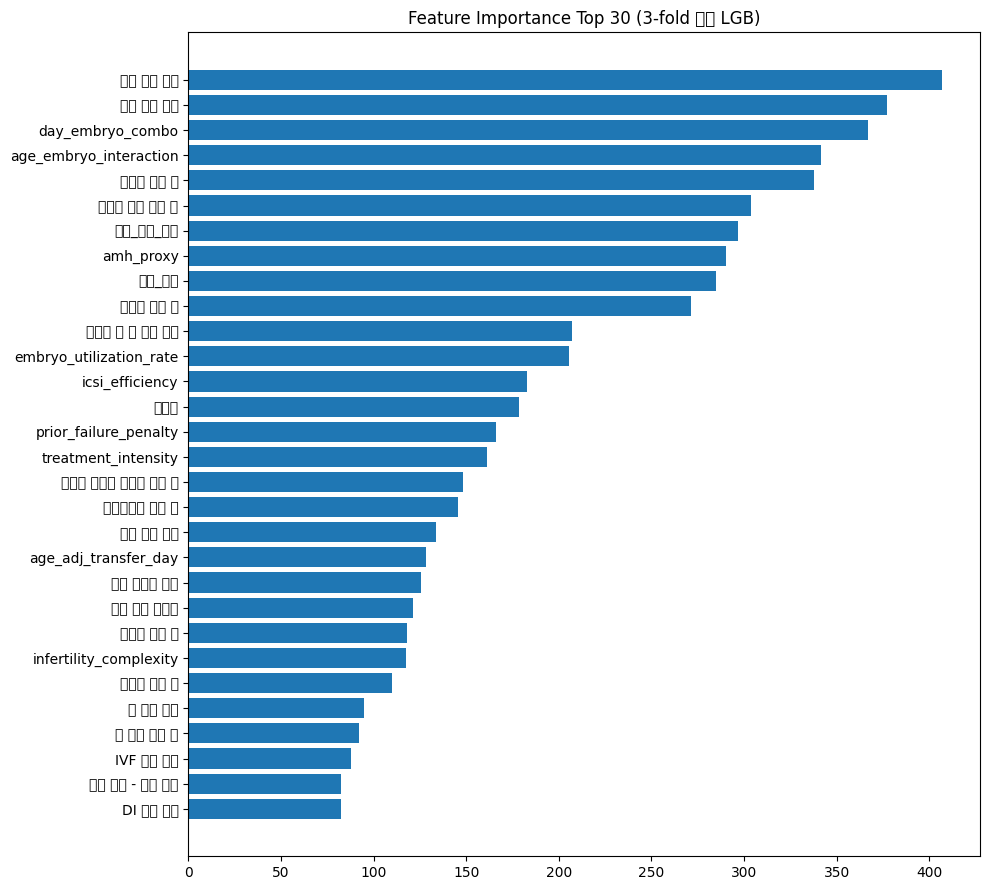


전체 feature: 103, importance>0: 83

신규 핵심 변수 순위:
                 feature  importance
2       day_embryo_combo  367.000000
19  age_adj_transfer_day  128.333333
35      is_day3_transfer   66.666667
50      is_day5_transfer   25.000000
74        has_blastocyst    2.000000
81             day_score    0.666667
82        procedure_dual    0.333333
95    transfer_day_known    0.000000


In [8]:
skf_imp = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
imp_list = []

for fold, (tr_idx, val_idx) in enumerate(skf_imp.split(X, y)):
    m = lgb.LGBMClassifier(
        **lgb_study.best_params,
        objective='binary', metric='auc', verbosity=-1, n_jobs=-1
    )
    m.fit(X.iloc[tr_idx], y.iloc[tr_idx],
          eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
          callbacks=[lgb.early_stopping(50, verbose=False)])
    imp_list.append(m.feature_importances_)
    print(f'  Fold {fold+1} AUC: {roc_auc_score(y.iloc[val_idx], m.predict_proba(X.iloc[val_idx])[:,1]):.5f}')

feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': np.mean(imp_list, axis=0)
}).sort_values('importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 9))
plt.barh(feat_imp['feature'].head(30), feat_imp['importance'].head(30))
plt.gca().invert_yaxis()
plt.title('Feature Importance Top 30 (3-fold 평균 LGB)')
plt.tight_layout()
plt.show()

print(f'\n전체 feature: {len(feat_imp)}, importance>0: {(feat_imp["importance"]>0).sum()}')
print('\n신규 핵심 변수 순위:')
key_features = ['day_score', 'is_day5_transfer', 'age_adj_transfer_day', 'day_embryo_combo',
                'has_blastocyst', 'procedure_dual', 'transfer_day_known', 'is_day3_transfer']
print(feat_imp[feat_imp['feature'].isin(key_features)][['feature', 'importance']].to_string())

## Feature Selection (importance > 0)

In [9]:
# importance > 0인 feature만 선택 (노이즈 컬럼 제거)
selected = feat_imp[feat_imp['importance'] > 0]['feature'].tolist()
X_final    = X[selected].copy()
test_final = test_df[selected].copy()

print(f'선택된 feature: {len(selected)} / {len(X.columns)}')
print(f'포함된 신규 핵심 변수: {[f for f in selected if f in key_features]}')

선택된 feature: 83 / 103
포함된 신규 핵심 변수: ['day_embryo_combo', 'age_adj_transfer_day', 'is_day3_transfer', 'is_day5_transfer', 'has_blastocyst', 'day_score', 'procedure_dual']


## OOF 앙상블 — LGB 단일 모델, 5-fold × 3 seeds

**v8 전략**: CatBoost 제거, LGB 단일 모델.
- 데이터 분석 결과: 단순 모델이 LB에서 더 좋음 (과적합 방지)
- 3 seeds × 5-fold = 15회 학습 (v7 30회의 절반)
- 실행시간 목표: 20~40분

In [10]:
SEEDS    = [42, 123, 2024]
N_SPLITS = 5

oof_all  = []
test_all = []

t_start = time.time()

for seed in SEEDS:
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    oof_pred  = np.zeros(len(X_final))
    test_pred = np.zeros(len(test_final))

    print(f'\n{"="*50} Seed {seed}')

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_final, y)):
        X_tr  = X_final.iloc[tr_idx].copy()
        X_val = X_final.iloc[val_idx].copy()
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        params = {
            **lgb_study.best_params,
            'objective': 'binary', 'metric': 'auc',
            'verbosity': -1, 'n_jobs': -1, 'random_state': seed
        }
        m = lgb.LGBMClassifier(**params)
        m.fit(X_tr, y_tr,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False)])

        oof_pred[val_idx]  = m.predict_proba(X_val)[:, 1]
        test_pred         += m.predict_proba(test_final.copy())[:, 1] / N_SPLITS

        fold_auc = roc_auc_score(y_val, oof_pred[val_idx])
        elapsed  = (time.time() - t_start) / 60
        print(f'  Fold {fold+1} | AUC {fold_auc:.5f} | {elapsed:.1f}min')

    seed_auc = roc_auc_score(y, oof_pred)
    print(f'  → OOF AUC (Seed {seed}): {seed_auc:.5f}')
    oof_all.append(oof_pred)
    test_all.append(test_pred)

# Seed 앙상블
oof_mean  = np.mean(oof_all, axis=0)
test_mean = np.mean(test_all, axis=0)

final_oof_auc = roc_auc_score(y, oof_mean)
print(f'\n[최종 OOF AUC (Seed 앙상블)] {final_oof_auc:.5f}')
print(f'총 소요시간: {(time.time()-t_start)/60:.1f}분')


================================================== Seed 42
  Fold 1 | AUC 0.73767 | 0.3min
  Fold 2 | AUC 0.74256 | 0.6min
  Fold 3 | AUC 0.73947 | 1.0min
  Fold 4 | AUC 0.73809 | 1.3min
  Fold 5 | AUC 0.74105 | 1.7min
  → OOF AUC (Seed 42): 0.73975

================================================== Seed 123
  Fold 1 | AUC 0.73799 | 2.0min
  Fold 2 | AUC 0.73966 | 2.4min
  Fold 3 | AUC 0.73916 | 2.8min
  Fold 4 | AUC 0.74007 | 3.2min
  Fold 5 | AUC 0.74169 | 3.6min
  → OOF AUC (Seed 123): 0.73970

================================================== Seed 2024
  Fold 1 | AUC 0.74195 | 3.9min
  Fold 2 | AUC 0.74023 | 4.3min
  Fold 3 | AUC 0.74030 | 4.7min
  Fold 4 | AUC 0.73822 | 5.0min
  Fold 5 | AUC 0.73875 | 5.5min
  → OOF AUC (Seed 2024): 0.73987

[최종 OOF AUC (Seed 앙상블)] 0.74016
총 소요시간: 5.5분


## 최종 예측 & 제출

In [11]:
final_preds = test_mean

submission = pd.DataFrame({'ID': test['ID'], 'probability': final_preds})
submission.to_csv('submission.csv', index=False)

print('submission.csv 저장 완료')
print(f'최종 OOF AUC: {final_oof_auc:.5f}')
print(submission.head())
print('\nprobability 통계:')
print(submission['probability'].describe())

submission.csv 저장 완료
최종 OOF AUC: 0.74016
           ID  probability
0  TEST_00000     0.001037
1  TEST_00001     0.001004
2  TEST_00002     0.152776
3  TEST_00003     0.109274
4  TEST_00004     0.517846

probability 통계:
count    90067.000000
mean         0.258442
std          0.160128
min          0.000665
25%          0.143853
50%          0.270482
75%          0.378446
max          0.729804
Name: probability, dtype: float64


## 변수 중요도 최종 확인

In [12]:
print('=== 최종 Feature Importance Top 20 ===')
print(feat_imp.head(20)[['feature', 'importance']].to_string())

print('\n=== v8 신규 추가 핵심 변수 순위 ===')
v8_new = ['day_score', 'age_adj_transfer_day', 'day_embryo_combo', 'is_day5_transfer',
          'is_day3_transfer', 'transfer_day_known', 'has_blastocyst', 'procedure_dual',
          'has_icsi', 'has_ah', 'embryo_for_current', 'embryo_for_donation',
          'infertility_complexity', 'icsi_efficiency']
print(feat_imp[feat_imp['feature'].isin(v8_new)][['feature', 'importance']].to_string())

=== 최종 Feature Importance Top 20 ===
                    feature  importance
0                  시술 시기 코드  407.000000
1                  시술 당시 나이  377.000000
2          day_embryo_combo  367.000000
3    age_embryo_interaction  341.666667
4                  이식된 배아 수  338.000000
5               수집된 신선 난자 수  304.000000
6                  배아_생성_효율  296.666667
7                 amh_proxy  290.333333
8                     이식_효율  284.666667
9                  저장된 배아 수  271.333333
10            클리닉 내 총 시술 횟수  207.333333
11  embryo_utilization_rate  205.666667
12          icsi_efficiency  183.000000
13                      실패율  178.333333
14    prior_failure_penalty  166.333333
15      treatment_intensity  161.333333
16         파트너 정자와 혼합된 난자 수  148.000000
17               미세주입된 난자 수  145.333333
18                 특정 시술 유형  133.666667
19     age_adj_transfer_day  128.333333

=== v8 신규 추가 핵심 변수 순위 ===
                    feature  importance
2          day_embryo_combo  367.000000
12          icsi